# Five-fold ROC / PR / ECE (mean ± std)

Three macro-averaged plots across the six models, for both test regimes —
$\mathbf{R}_{L2}$ (no-spurious, solid) and $\mathbf{R}_{L1}$ (spurious, dotted).
Each curve is the mean over the 5 CV folds with a ±1σ shaded band; legend
scalars (AUC / AP / ECE) are reported as mean ± std.

**Input** (in `plot_data/`): `cv_predictions_no_spurious.csv`, `cv_predictions_spurious.csv`
— each with columns `model_name, fold, y_true, prob_nat, prob_sfri, prob_sfrii, prob_wat`.

Run top to bottom. The three figures render inline and are also saved to `plot_data/plots/`.


In [ ]:
# ── Paths ────────────────────────────────────────────────────────────────────
from pathlib import Path

# Works whether Jupyter is launched from the repo root or from notebooks/.
_cwd = Path.cwd()
REPO_ROOT = next(
    (p for p in (_cwd, *_cwd.parents)
     if (p / "plot_data").is_dir() and (p / "notebooks").is_dir()),
    _cwd,
)
#main dir = /media/aristotle/shahal/old/rgc_1/final_rgc/newdata_set/all_5_folds_final
DATA_DIR  = REPO_ROOT / "plot_data"
PLOTS_DIR = DATA_DIR / "plots"

CSV_NO_SPURIOUS = DATA_DIR / "cv_predictions_no_spurious.csv"   # R_L2
CSV_SPURIOUS    = DATA_DIR / "cv_predictions_spurious.csv"      # R_L1

for _p in (CSV_NO_SPURIOUS, CSV_SPURIOUS):
    assert _p.is_file(), f"missing input CSV: {_p}"
print("data dir:", DATA_DIR)
print("plots ->:", PLOTS_DIR)

data dir: /home/gate/rgc/plot_data
plots ->: /home/gate/rgc/plot_data/plots


In [5]:
# ── Plotting library (macro ROC / PR / ECE with per-fold mean +/- std) ──
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.text as _mtext
import numpy as np
import pandas as pd
from matplotlib.legend_handler import HandlerBase as _HandlerBase
from matplotlib.lines import Line2D
from sklearn.metrics import (
    auc,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
)
from sklearn.preprocessing import label_binarize


# ════════════════════════════════════════════════════════════════════
# Configuration
# ════════════════════════════════════════════════════════════════════
CLASS_NAMES = ["nat", "sfri", "sfrii", "wat"]
PROB_COLS   = [f"prob_{c}" for c in CLASS_NAMES]
N_BINS_ECE  = 15  # reduced from 15 for smoother curves

LS_NO_SPURIOUS = "-"   # R_L2
LS_SPURIOUS    = ":"   # R_L1

LABEL_RL2 = r"$\mathbf{R}_{L2}$"
LABEL_RL1 = r"$\mathbf{R}_{L1}$"

# ── Global font sizes ──────────────────────────────────────────────
FONT_SIZE       = 20
FONT_SIZE_SMALL = int(round(FONT_SIZE * 0.9))
FONT_SIZE_LARGE = int(round(FONT_SIZE * 1.2))

plt.rcParams.update(
    {
        "font.size":             FONT_SIZE,
        "axes.titlesize":        FONT_SIZE_LARGE,
        "axes.labelsize":        FONT_SIZE,
        "xtick.labelsize":       FONT_SIZE_SMALL,
        "ytick.labelsize":       FONT_SIZE_SMALL,
        "legend.fontsize":       FONT_SIZE_SMALL,
        "legend.title_fontsize": FONT_SIZE_SMALL,
        "figure.titlesize":      FONT_SIZE_LARGE,
    }
)

# ── Model colours: worst → best combined accuracy ──────────────────
RAINBOW_MODEL_HEX = [
    "#ff3b30",  # red    – worst
    "#ff9500",  # orange
    "#ffcc00",  # yellow
    "#34c759",  # green
    "#0a84ff",  # blue
    "#bf5af2",  # violet – best
]

MODEL_DISPLAY_NAMES: dict[str, str] = {
    "byol_dsteerable_downstream": "BYOL-E2CNN",
    "resnet50":                   "ResNet-50",
    "convnext_base":              "ConvNeXT",
    "swin_b":                     "Swin-B",
    "vit_b_16":                   "ViT-B/16",
    "vgg16":                      "VGG-16",
}

MODEL_SERIAL_ORDER = [
    "ConvNeXT", "BYOL-E2CNN", "VGG-16", "Swin-B", "ResNet-50", "ViT-B/16",
]
MODEL_LABEL_BY_NAME = {
    name: f"$M_{i}$"
    for i, name in enumerate(MODEL_SERIAL_ORDER, start=1)
}


def display_name(folder: str) -> str:
    return MODEL_DISPLAY_NAMES.get(folder, folder.replace("_", " ").title())


# ════════════════════════════════════════════════════════════════════
# Legend handlers (from notebook)
# ════════════════════════════════════════════════════════════════════
class _PrefixedLine:
    __slots__ = ("prefix", "line")
    def __init__(self, prefix: str, line: Line2D):
        self.prefix = prefix
        self.line   = line


LINE_START = 0.55


class PrefixLineHandler(_HandlerBase):
    def create_artists(self, legend, handle, xd, yd, width, height, fontsize, trans):
        y = yd + height / 2
        txt = _mtext.Text(
            xd, y, handle.prefix,
            transform=trans, fontsize=fontsize,
            va="center", ha="left", clip_on=False,
        )
        line = Line2D(
            [xd + width * LINE_START, xd + width], [y, y], transform=trans,
        )
        line.update_from(handle.line)
        return [txt, line]


class _IndentedLine:
    __slots__ = ("line",)
    def __init__(self, line: Line2D):
        self.line = line


class IndentedLineHandler(_HandlerBase):
    def create_artists(self, legend, handle, xd, yd, width, height, fontsize, trans):
        y = yd + height / 2
        line = Line2D(
            [xd + width * LINE_START, xd + width], [y, y], transform=trans,
        )
        line.update_from(handle.line)
        return [line]


# ════════════════════════════════════════════════════════════════════
# Helpers
# ════════════════════════════════════════════════════════════════════
def _row_normalize_probs(probs: np.ndarray) -> np.ndarray:
    probs = np.asarray(probs, dtype=float)
    s = probs.sum(axis=1, keepdims=True)
    s[s == 0.0] = 1.0
    return probs / s


def _make_bin_edges(
    conf: np.ndarray, n_bins: int, strategy: str = "quantile",
) -> np.ndarray:
    if strategy == "quantile":
        quantiles = np.linspace(0, 1, n_bins + 1)
        edges = np.percentile(conf, quantiles * 100)
        edges[0]  = 0.0
        edges[-1] = 1.0
        return edges
    return np.linspace(0.0, 1.0, n_bins + 1)


def ece_multiclass(
    probs: np.ndarray,
    y_true: np.ndarray,
    n_bins: int = 10,
    strategy: str = "quantile",
) -> float:
    probs   = _row_normalize_probs(probs)
    y_true  = np.asarray(y_true)
    conf    = probs.max(axis=1)
    pred    = probs.argmax(axis=1)
    correct = (pred == y_true).astype(float)
    bins = _make_bin_edges(conf, n_bins, strategy)
    ece, n = 0.0, len(y_true)
    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        m = (
            (conf >= lo) & (conf <= hi)
            if i == n_bins - 1
            else (conf >= lo) & (conf < hi)
        )
        if not np.any(m):
            continue
        ece += (m.sum() / n) * abs(correct[m].mean() - conf[m].mean())
    return float(ece)


# Common confidence grid for interpolation
CONF_GRID = np.linspace(0.0, 1.0, 201)


def reliability_on_grid(
    probs: np.ndarray,
    y_true: np.ndarray,
    n_bins: int,
    grid: np.ndarray,
    strategy: str = "quantile",
) -> np.ndarray:
    """
    Compute per-bin (mean_conf, accuracy) then interpolate onto *grid*.
    Returns array of shape (len(grid),) with NaN outside observed range.
    """
    probs   = _row_normalize_probs(probs)
    y_true  = np.asarray(y_true, dtype=int)
    conf    = probs.max(axis=1)
    pred    = probs.argmax(axis=1)
    correct = (pred == y_true).astype(float)
    bins = _make_bin_edges(conf, n_bins, strategy)

    bin_conf, bin_acc = [], []
    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        msk = (
            (conf >= lo) & (conf <= hi)
            if i == n_bins - 1
            else (conf >= lo) & (conf < hi)
        )
        if not np.any(msk):
            continue
        bin_conf.append(conf[msk].mean())
        bin_acc.append(correct[msk].mean())

    if len(bin_conf) < 2:
        return np.full_like(grid, np.nan)

    bx = np.array(bin_conf)
    by = np.array(bin_acc)
    order = np.argsort(bx)
    bx, by = bx[order], by[order]

    return np.interp(grid, bx, by, left=np.nan, right=np.nan)


# ── ROC helpers ────────────────────────────────────────────────────
ROC_GRID = np.linspace(0.0, 1.0, 1001)


def macro_roc_on_grid(
    probs: np.ndarray,
    y_true: np.ndarray,
    grid: np.ndarray = ROC_GRID,
    n_classes: int = 4,
) -> tuple[np.ndarray, float]:
    """
    Compute macro-averaged ROC curve interpolated onto *grid*.

    Returns (tpr_on_grid, macro_auc).
    """
    probs  = _row_normalize_probs(probs)
    y_true = np.asarray(y_true)
    y_bin  = label_binarize(y_true, classes=list(range(n_classes)))

    per_class_tpr = []
    per_class_auc = []
    for c in range(n_classes):
        fpr_c, tpr_c, _ = roc_curve(y_bin[:, c], probs[:, c])
        per_class_tpr.append(np.interp(grid, fpr_c, tpr_c))
        per_class_tpr[-1][0] = 0.0
        per_class_auc.append(auc(fpr_c, tpr_c))

    mean_tpr  = np.mean(per_class_tpr, axis=0)
    macro_auc = float(np.mean(per_class_auc))
    return mean_tpr, macro_auc


# ── PR helpers ─────────────────────────────────────────────────────
PR_GRID = np.linspace(0.0, 1.0, 1001)


def macro_pr_on_grid(
    probs: np.ndarray,
    y_true: np.ndarray,
    grid: np.ndarray = PR_GRID,
    n_classes: int = 4,
) -> tuple[np.ndarray, float]:
    """
    Compute macro-averaged PR curve interpolated onto *grid* (recall axis).

    Returns (precision_on_grid, macro_ap).
    """
    probs  = _row_normalize_probs(probs)
    y_true = np.asarray(y_true)
    y_bin  = label_binarize(y_true, classes=list(range(n_classes)))

    per_class_prec = []
    for c in range(n_classes):
        prec_c, rec_c, _ = precision_recall_curve(y_bin[:, c], probs[:, c])
        # PR curve comes in decreasing-recall order; sort ascending for interp
        order = np.argsort(rec_c)
        per_class_prec.append(np.interp(grid, rec_c[order], prec_c[order]))

    mean_prec = np.mean(per_class_prec, axis=0)
    macro_ap  = float(average_precision_score(y_bin, probs, average="macro"))
    return mean_prec, macro_ap


# ════════════════════════════════════════════════════════════════════
# Data loading
# ════════════════════════════════════════════════════════════════════
def load_regime_csv(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    required = set(PROB_COLS + ["y_true", "model_name", "fold"])
    miss = required - set(df.columns)
    if miss:
        raise ValueError(f"{path} missing columns: {sorted(miss)}")
    return df


def combined_accuracy(
    df_rl2: pd.DataFrame, df_rl1: pd.DataFrame, model: str,
) -> float:
    """Combined accuracy across both regimes for rainbow ranking."""
    sub2 = df_rl2[df_rl2["model_name"] == model]
    sub1 = df_rl1[df_rl1["model_name"] == model]
    p2 = _row_normalize_probs(sub2[PROB_COLS].to_numpy())
    p1 = _row_normalize_probs(sub1[PROB_COLS].to_numpy())
    y2 = sub2["y_true"].to_numpy()
    y1 = sub1["y_true"].to_numpy()
    correct = int((p2.argmax(1) == y2).sum() + (p1.argmax(1) == y1).sum())
    return float(correct / max(len(y2) + len(y1), 1))


# ════════════════════════════════════════════════════════════════════
# Plotting
# ════════════════════════════════════════════════════════════════════
def plot_ece_mean_std(
    df_rl2: pd.DataFrame,
    df_rl1: pd.DataFrame,
    models_rainbow: list[str],
    model_colours: dict[str, str],
    out_path: Path,
    n_bins: int = N_BINS_ECE,
):
    fig, ax = plt.subplots(figsize=(9.5, 9.5))

    # sort by serial order for legend
    models_serial = sorted(
        models_rainbow,
        key=lambda m: MODEL_SERIAL_ORDER.index(display_name(m)),
    )

    legend_handles: list = []
    legend_labels:  list = []

    for model in models_serial:
        dname       = display_name(model)
        color       = model_colours[model]
        model_label = MODEL_LABEL_BY_NAME[dname]

        ece_means: list[float] = []
        ece_stds:  list[float] = []

        for df_regime, ls in [
            (df_rl2, LS_NO_SPURIOUS),
            (df_rl1, LS_SPURIOUS),
        ]:
            sub = df_regime[df_regime["model_name"] == model]
            if sub.empty:
                continue

            folds = sorted(sub["fold"].unique())

            fold_curves = []
            fold_eces   = []
            for f in folds:
                sf    = sub[sub["fold"] == f]
                y     = sf["y_true"].to_numpy(dtype=int)
                probs = _row_normalize_probs(sf[PROB_COLS].to_numpy())

                fold_eces.append(ece_multiclass(probs, y, n_bins=n_bins))
                fold_curves.append(
                    reliability_on_grid(probs, y, n_bins, CONF_GRID)
                )

            curves = np.array(fold_curves)  # (K, 201)
            valid  = ~np.any(np.isnan(curves), axis=0)

            mean_curve = np.nanmean(curves, axis=0)
            std_curve  = np.nanstd(curves, axis=0)

            gv = CONF_GRID[valid]
            mv = mean_curve[valid]
            sv = std_curve[valid]

            ax.plot(gv, mv, lw=2, ls=ls, color=color)
            ax.fill_between(
                gv,
                np.clip(mv - sv, 0, 1),
                np.clip(mv + sv, 0, 1),
                color=color,
                alpha=0.12,
            )

            ece_means.append(float(np.mean(fold_eces)))
            ece_stds.append(float(np.std(fold_eces)))

        # legend order: R_L2 first, R_L1 second (matches loop order)
        e2_mean, e1_mean = ece_means
        e2_std,  e1_std  = ece_stds

        rl1_line = Line2D([0], [0], color=color, ls=":", lw=2)
        legend_handles.append(_PrefixedLine(model_label, rl1_line))
        legend_labels.append(
            f"  {LABEL_RL1}  {e1_mean:.2f}" + r"$\pm$" + f"{e1_std:.2f}"
        )

        rl2_line = Line2D([0], [0], color=color, ls="-", lw=2)
        legend_handles.append(_IndentedLine(rl2_line))
        legend_labels.append(
            f"  {LABEL_RL2}  {e2_mean:.2f}" + r"$\pm$" + f"{e2_std:.2f}"
        )

    ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.6)
    ax.set_xlim(.4, 1.0)
    ax.set_ylim(0.3, 1.0)
    ax.set_xlabel("Mean predicted probability (confidence)")
    ax.set_ylabel("Fraction of positives (accuracy)")
    ax.legend(
        legend_handles,
        legend_labels,
        handler_map={
            _PrefixedLine:  PrefixLineHandler(),
            _IndentedLine:  IndentedLineHandler(),
        },
        loc="upper left",
        fontsize=15,
        ncol=1,
        handlelength=4.5,
        framealpha=0.55,
        fancybox=False,
    )

    out_path.parent.mkdir(parents=True, exist_ok=True)
    fig.tight_layout()
    fig.savefig(out_path, dpi=100)
    fig.savefig(out_path.with_suffix(".png"), dpi=200)
    plt.show()
    print("Wrote:", out_path)
    print("Wrote:", out_path.with_suffix(".png"))


def plot_roc_mean_std(
    df_rl2: pd.DataFrame,
    df_rl1: pd.DataFrame,
    models_rainbow: list[str],
    model_colours: dict[str, str],
    out_path: Path,
):
    fig, ax = plt.subplots(figsize=(9.5, 7.5))

    models_serial = sorted(
        models_rainbow,
        key=lambda m: MODEL_SERIAL_ORDER.index(display_name(m)),
    )

    legend_handles: list = []
    legend_labels:  list = []

    for model in models_serial:
        dname       = display_name(model)
        color       = model_colours[model]
        model_label = MODEL_LABEL_BY_NAME[dname]

        auc_means: list[float] = []
        auc_stds:  list[float] = []

        for df_regime, ls in [
            (df_rl2, LS_NO_SPURIOUS),
            (df_rl1, LS_SPURIOUS),
        ]:
            sub = df_regime[df_regime["model_name"] == model]
            if sub.empty:
                continue

            folds = sorted(sub["fold"].unique())

            fold_tprs = []
            fold_aucs = []
            for f in folds:
                sf    = sub[sub["fold"] == f]
                y     = sf["y_true"].to_numpy(dtype=int)
                probs = _row_normalize_probs(sf[PROB_COLS].to_numpy())

                tpr, auc_val = macro_roc_on_grid(probs, y)
                fold_tprs.append(tpr)
                fold_aucs.append(auc_val)

            tprs = np.array(fold_tprs)  # (K, 1001)
            mean_tpr = np.mean(tprs, axis=0)
            std_tpr  = np.std(tprs, axis=0)

            ax.plot(ROC_GRID, mean_tpr, lw=2, ls=ls, color=color)
            ax.fill_between(
                ROC_GRID,
                np.clip(mean_tpr - std_tpr, 0, 1),
                np.clip(mean_tpr + std_tpr, 0, 1),
                color=color,
                alpha=0.12,
            )

            auc_means.append(float(np.mean(fold_aucs)))
            auc_stds.append(float(np.std(fold_aucs)))

        a2_mean, a1_mean = auc_means
        a2_std,  a1_std  = auc_stds

        rl1_line = Line2D([0], [0], color=color, ls=":", lw=2)
        legend_handles.append(_PrefixedLine(model_label, rl1_line))
        legend_labels.append(
            f"  {LABEL_RL1}  {a1_mean:.2f}" + r"$\pm$" + f"{a1_std:.2f}"
        )

        rl2_line = Line2D([0], [0], color=color, ls="-", lw=2)
        legend_handles.append(_IndentedLine(rl2_line))
        legend_labels.append(
            f"  {LABEL_RL2}  {a2_mean:.2f}" + r"$\pm$" + f"{a2_std:.2f}"
        )

    ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.6)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(
        legend_handles, legend_labels,
        handler_map={
            _PrefixedLine:  PrefixLineHandler(),
            _IndentedLine:  IndentedLineHandler(),
        },
        loc="lower right", fontsize=15, ncol=1, framealpha=0.95,
        handlelength=4.5,
    )

    out_path.parent.mkdir(parents=True, exist_ok=True)
    fig.tight_layout()
    fig.savefig(out_path, dpi=100)
    fig.savefig(out_path.with_suffix(".png"), dpi=200)
    plt.show()
    print("Wrote:", out_path)
    print("Wrote:", out_path.with_suffix(".png"))


def plot_pr_mean_std(
    df_rl2: pd.DataFrame,
    df_rl1: pd.DataFrame,
    models_rainbow: list[str],
    model_colours: dict[str, str],
    out_path: Path,
):
    fig, ax = plt.subplots(figsize=(9.5, 7.5))

    models_serial = sorted(
        models_rainbow,
        key=lambda m: MODEL_SERIAL_ORDER.index(display_name(m)),
    )

    legend_handles: list = []
    legend_labels:  list = []

    for model in models_serial:
        dname       = display_name(model)
        color       = model_colours[model]
        model_label = MODEL_LABEL_BY_NAME[dname]

        ap_means: list[float] = []
        ap_stds:  list[float] = []

        for df_regime, ls in [
            (df_rl2, LS_NO_SPURIOUS),
            (df_rl1, LS_SPURIOUS),
        ]:
            sub = df_regime[df_regime["model_name"] == model]
            if sub.empty:
                continue

            folds = sorted(sub["fold"].unique())

            fold_precs = []
            fold_aps   = []
            for f in folds:
                sf    = sub[sub["fold"] == f]
                y     = sf["y_true"].to_numpy(dtype=int)
                probs = _row_normalize_probs(sf[PROB_COLS].to_numpy())

                prec, ap_val = macro_pr_on_grid(probs, y)
                fold_precs.append(prec)
                fold_aps.append(ap_val)

            precs = np.array(fold_precs)  # (K, 1001)
            mean_prec = np.mean(precs, axis=0)
            std_prec  = np.std(precs, axis=0)

            ax.plot(PR_GRID, mean_prec, lw=2, ls=ls, color=color)
            ax.fill_between(
                PR_GRID,
                np.clip(mean_prec - std_prec, 0, 1),
                np.clip(mean_prec + std_prec, 0, 1),
                color=color,
                alpha=0.12,
            )

            ap_means.append(float(np.mean(fold_aps)))
            ap_stds.append(float(np.std(fold_aps)))

        a2_mean, a1_mean = ap_means
        a2_std,  a1_std  = ap_stds

        rl1_line = Line2D([0], [0], color=color, ls=":", lw=2)
        legend_handles.append(_PrefixedLine(model_label, rl1_line))
        legend_labels.append(
            f"  {LABEL_RL1}  {a1_mean:.2f}" + r"$\pm$" + f"{a1_std:.2f}"
        )

        rl2_line = Line2D([0], [0], color=color, ls="-", lw=2)
        legend_handles.append(_IndentedLine(rl2_line))
        legend_labels.append(
            f"  {LABEL_RL2}  {a2_mean:.2f}" + r"$\pm$" + f"{a2_std:.2f}"
        )

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.legend(
        legend_handles, legend_labels,
        handler_map={
            _PrefixedLine:  PrefixLineHandler(),
            _IndentedLine:  IndentedLineHandler(),
        },
        loc="lower left", fontsize=15, ncol=1, framealpha=0.95,
        handlelength=4.5,
    )

    out_path.parent.mkdir(parents=True, exist_ok=True)
    fig.tight_layout()
    fig.savefig(out_path, dpi=100)
    fig.savefig(out_path.with_suffix(".png"), dpi=200)
    plt.show()
    print("Wrote:", out_path)
    print("Wrote:", out_path.with_suffix(".png"))
# ════════════════════════════════════════════════════════════════════

Found 6 models in both regimes:
  BYOL-E2CNN       RL2: 1648 rows, folds [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]  |  RL1: 2060 rows, folds [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
  ConvNeXT         RL2: 2060 rows, folds [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]  |  RL1: 2060 rows, folds [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
  ResNet-50        RL2: 2472 rows, folds [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]  |  RL1: 2060 rows, folds [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
  Swin-B           RL2: 2060 rows, folds [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]  |  RL1: 2060 rows, folds [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
  VGG-16           RL2: 2060 rows, folds [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]  |  RL1: 2060 rows, folds [np.int64(0), np.int64(1), np.int64(2), np.int64(3),

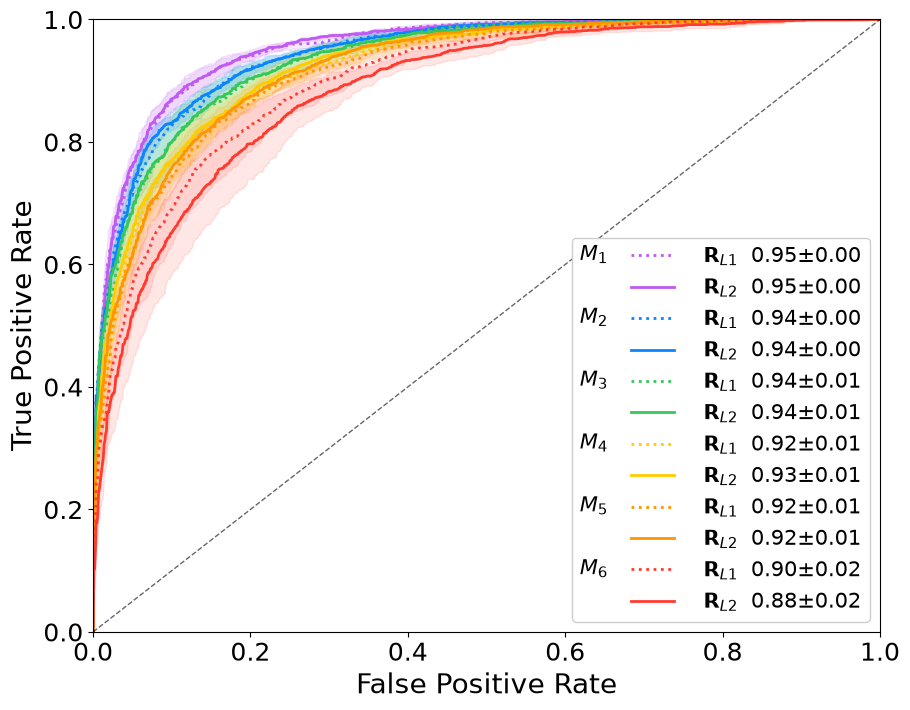

Wrote: /home/gate/rgc/plot_data/plots/roc_models_two_datasets.pdf
Wrote: /home/gate/rgc/plot_data/plots/roc_models_two_datasets.png


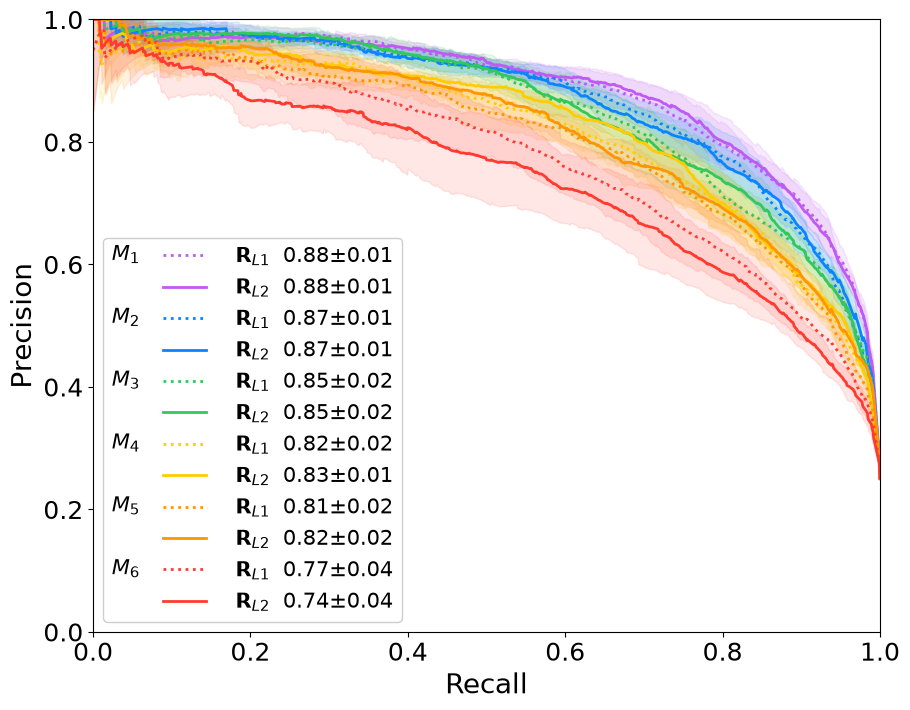

Wrote: /home/gate/rgc/plot_data/plots/pr_models_two_datasets.pdf
Wrote: /home/gate/rgc/plot_data/plots/pr_models_two_datasets.png


/tmp/ipykernel_1654078/3436824176.py:366: RuntimeWarning: Mean of empty slice
  mean_curve = np.nanmean(curves, axis=0)
/home/gate/rgc/.rgc/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_1654078/3436824176.py:366: RuntimeWarning: Mean of empty slice
  mean_curve = np.nanmean(curves, axis=0)
/home/gate/rgc/.rgc/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_1654078/3436824176.py:366: RuntimeWarning: Mean of empty slice
  mean_curve = np.nanmean(curves, axis=0)
/home/gate/rgc/.rgc/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_1654078/3436824176.py:366

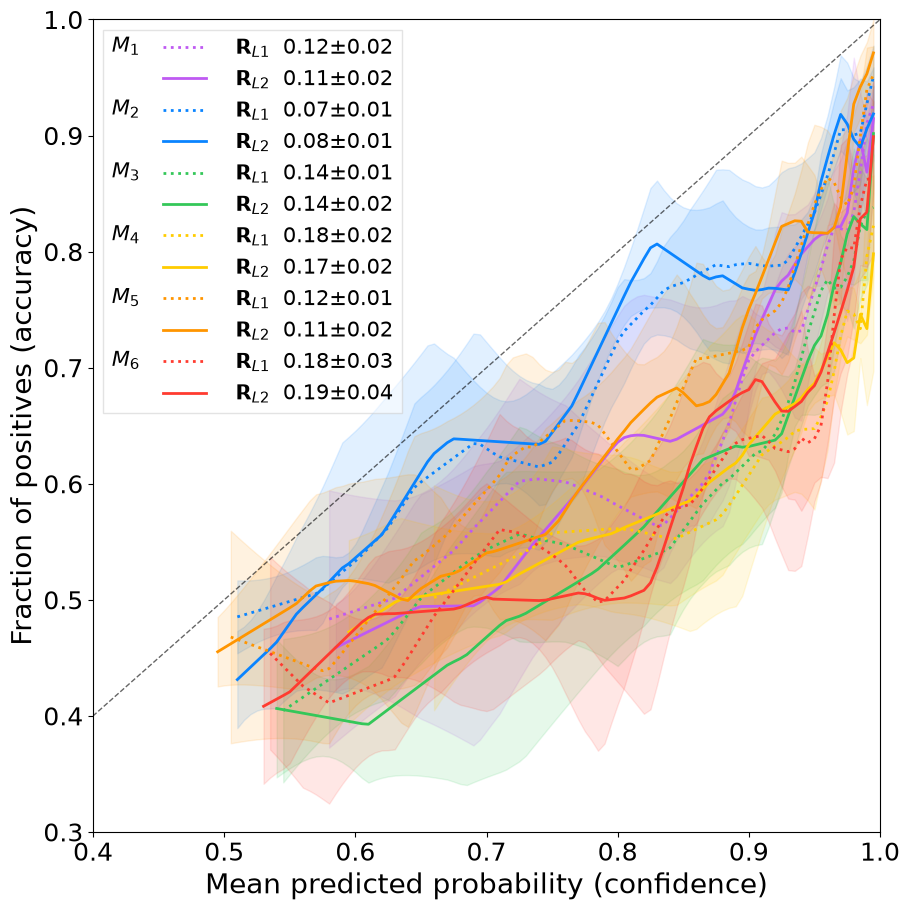

Wrote: /home/gate/rgc/plot_data/plots/ece_models_two_datasets_n.pdf
Wrote: /home/gate/rgc/plot_data/plots/ece_models_two_datasets_n.png


In [6]:
# ── Run: load the two CSVs and generate the three plots ──
df_rl2 = load_regime_csv(CSV_NO_SPURIOUS)
df_rl1 = load_regime_csv(CSV_SPURIOUS)

# discover models present in both regimes
models_both = sorted(
    set(df_rl2["model_name"].unique()) & set(df_rl1["model_name"].unique())
)
print(f"Found {len(models_both)} models in both regimes:")
for m in models_both:
    n2 = len(df_rl2[df_rl2["model_name"] == m])
    n1 = len(df_rl1[df_rl1["model_name"] == m])
    folds2 = sorted(df_rl2[df_rl2["model_name"] == m]["fold"].unique())
    folds1 = sorted(df_rl1[df_rl1["model_name"] == m]["fold"].unique())
    print(f"  {display_name(m):15s}  RL2: {n2} rows, folds {folds2}  |  RL1: {n1} rows, folds {folds1}")
print()

# rainbow order: worst → best combined accuracy
models_rainbow = sorted(
    models_both,
    key=lambda m: combined_accuracy(df_rl2, df_rl1, m),
)
model_colours = {
    m: RAINBOW_MODEL_HEX[min(i, len(RAINBOW_MODEL_HEX) - 1)]
    for i, m in enumerate(models_rainbow)
}

print("Model colour assignments (worst → best combined accuracy):")
for m in models_rainbow:
    acc = combined_accuracy(df_rl2, df_rl1, m)
    print(f"  {model_colours[m]}  {display_name(m):15s}  acc={acc:.4f}")
print()

out_roc = PLOTS_DIR / "fig4_roc.pdf"
plot_roc_mean_std(df_rl2, df_rl1, models_rainbow, model_colours, out_roc)

out_pr = PLOTS_DIR / "fig4_pr.pdf"
plot_pr_mean_std(df_rl2, df_rl1, models_rainbow, model_colours, out_pr)


out_ece = PLOTS_DIR / "fig5_ece.pdf"
plot_ece_mean_std(df_rl2, df_rl1, models_rainbow, model_colours, out_ece)